In [37]:
import pyarrow.parquet as pq
import pyarrow.compute as pc
import pyarrow.dataset as ds
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import numpy as np


In [38]:
path = "../data/final/all_reviews_full_with_genres.parquet"
dataset = ds.dataset(path, format="parquet")

df = (
    dataset
    .scanner(columns=["appid", "review", "voted_up"])
    .head(500_000)     # temporary larger pool
    .to_pandas()
)

In [39]:

df_capped = (
    df
    .groupby("appid", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), 500),
        random_state=42
    ))
)


/tmp/ipykernel_404/106479707.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [40]:
df_capped["appid"].nunique()


862

In [41]:
df_capped["appid"].value_counts().head(10)
#sees app ID dominance = vocabulary dominated by one game's terminology, inflated performance, poor generalization


appid
10         500
1005300    500
1008710    500
1008580    500
1008080    500
1008020    500
100        500
1007810    500
1007400    500
1007350    500
Name: count, dtype: int64

In [42]:
df_capped.shape



(73661, 3)

In [43]:
df_capped["appid"].value_counts().describe()


count    862.000000
mean      85.453596
std      146.164202
min        1.000000
25%        6.000000
50%       18.000000
75%       79.000000
max      500.000000
Name: count, dtype: float64

In [44]:
df_capped["voted_up"].value_counts(normalize=True)



voted_up
True     0.797763
False    0.202237
Name: proportion, dtype: float64

In [45]:
df_capped = df_capped.drop(columns=["appid"])


In [46]:
df_capped.shape



(73661, 2)

In [47]:
df_capped.to_parquet(
    "steam_reviews_model1_text_only.parquet",
    index=False
)


In [48]:
data = pd.read_parquet("steam_reviews_model1_text_only.parquet")
data = data.dropna(subset=["review"])
data = data[data["review"].str.strip().str.len() > 0]


In [49]:
data["review"].isna().sum()
data["review"].map(type).value_counts().head()


review
<class 'str'>    73645
Name: count, dtype: int64

In [50]:
data["voted_up"].value_counts(normalize=True)


voted_up
True     0.797719
False    0.202281
Name: proportion, dtype: float64

In [51]:
data["review"].str.len().describe()


count       73645.0
mean     296.121828
std      645.170315
min             1.0
25%            23.0
50%            81.0
75%           278.0
max          7999.0
Name: review, dtype: Float64

In [52]:
X = data["review"]
y = data["voted_up"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [53]:
model_lr = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=40_000,   # 74k docs → this is enough
        ngram_range=(1, 2),
        stop_words="english",
        min_df=5
    )),
    ("lr", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1
    ))
])

model_lr.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=40000, min_df=5,
                                 ngram_range=(1, 2), stop_words='english')),
                ('lr',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    n_jobs=-1))])

In [54]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model_lr.predict(X_test)
y_prob = model_lr.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       0.53      0.62      0.57      2979
           1       0.90      0.86      0.88     11750

    accuracy                           0.81     14729
   macro avg       0.72      0.74      0.73     14729
weighted avg       0.83      0.81      0.82     14729

ROC AUC: 0.8527685572054025


In [55]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)


array([[ 1854,  1125],
       [ 1631, 10119]])

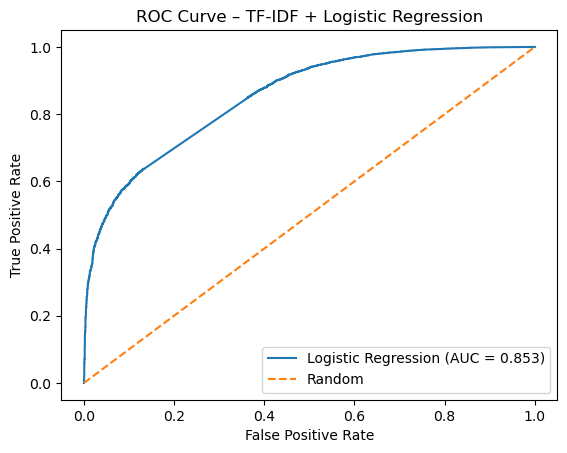

In [56]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – TF-IDF + Logistic Regression")
plt.legend()
plt.show()


In [57]:
from sklearn.naive_bayes import MultinomialNB

model_nb = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=40_000,
        ngram_range=(1, 2),
        stop_words="english",
        min_df=5
    )),
    ("nb", MultinomialNB(alpha=0.5))
])

model_nb.fit(X_train, y_train)

y_pred_nb = model_nb.predict(X_test)
y_prob_nb = model_nb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_nb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_nb))


              precision    recall  f1-score   support

           0       0.81      0.26      0.39      2979
           1       0.84      0.98      0.91     11750

    accuracy                           0.84     14729
   macro avg       0.82      0.62      0.65     14729
weighted avg       0.83      0.84      0.80     14729

ROC AUC: 0.8375621692271432


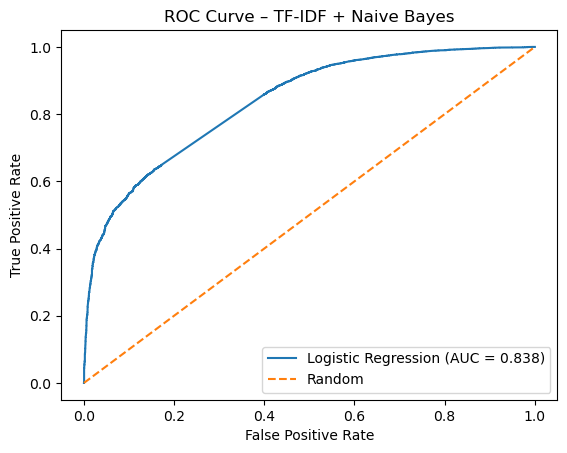

In [58]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_nb)
auc = roc_auc_score(y_test, y_prob_nb)

plt.figure()
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – TF-IDF + Naive Bayes")
plt.legend()
plt.show()

In [59]:

tfidf = model_lr.named_steps["tfidf"]
lr = model_lr.named_steps["lr"]

feature_names = tfidf.get_feature_names_out()
coefs = lr.coef_[0]

top_pos = feature_names[np.argsort(coefs)[-20:]]
top_neg = feature_names[np.argsort(coefs)[:20]]

top_pos, top_neg


(array(['beautiful', 'highly', 'bon', 'fun', 'solid', 'yes', 'fantastic',
        'unique', 'cool', 'awesome', 'enjoyed', 'nice', 'good',
        'excellent', 'definitely', 'amazing', 'love', 'best', '10 10',
        'great'], dtype=object),
 array(['boring', 'terrible', 'nicht', 'unplayable', 'refund', 'waste',
        'worst', 'horrible', 'não', 'garbage', 'не рекомендую', 'broken',
        'buggy', 'money', 'poorly', 'disappointed', 'don', 'worse', 'kötü',
        'unfortunately'], dtype=object))

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.pipeline import Pipeline

# meta-only preprocessor (reuse your numeric_pipe + categorical_pipe)
meta_preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

def eval_model(name, model):
    pipe = Pipeline([("prep", meta_preprocess), ("clf", model)])
    pipe.fit(X_train, y_train)

    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)

    cm = confusion_matrix(y_test, pred, labels=[0, 1])
    prec, rec, _, _ = precision_recall_fscore_support(y_test, pred, labels=[0,1], zero_division=0)

    return {
        "Model": name,
        "ROC_AUC": roc_auc_score(y_test, proba),
        "PR_AUC": average_precision_score(y_test, proba),
        "F1_pos": f1_score(y_test, pred),
        "Accuracy": accuracy_score(y_test, pred),
        "Neg_Prec": prec[0],
        "Neg_Rec": rec[0],
        "_cm": cm
    }

tree_results = []

tree_results.append(eval_model(
    "DecisionTree (meta-only)",
    DecisionTreeClassifier(max_depth=8, random_state=42)
))

tree_results.append(eval_model(
    "RandomForest (meta-only)",
    RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42
    )
))

tree_df = pd.DataFrame([{k:v for k,v in r.items() if k!="_cm"} for r in tree_results])
print(tree_df.to_string(index=False))

for r in tree_results:
    print("\n", r["Model"])
    print(r["_cm"])
